# Phase 1: Data Continuity Inspection (Data Reliability Filter)

This notebook performs a comprehensive continuity analysis of the measurements table in the HRP processed database. We'll analyze:
1. **Sampling Audit**
2. **Gap Analysis**
4. **Data Density** 
5. **High vs Low Quality Data**
6. **Alert-Centric Data Quality**

## Section 1: Import Required Libraries

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
import pickle
import json
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

## Section 2: Connect to Database

In [2]:
db_path = '../db/hrp_processed.db'
conn = sqlite3.connect(db_path)
print(f"Connected to: {db_path}")

Connected to: ../db/hrp_processed.db


In [ ]:
# Verify
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM measurements;")
total_measurements = cursor.fetchone()[0]
cursor.execute("SELECT COUNT(DISTINCT senior_id) FROM measurements;")
unique_seniors = cursor.fetchone()[0]
cursor.execute("SELECT DISTINCT type FROM measurements;")
measurement_types = [row[0] for row in cursor.fetchall()]

print(f"Total measurements: {total_measurements:,}")
print(f"Unique seniors: {unique_seniors:,}")
print(f"Measurement types: {sorted(measurement_types)}")

Total measurements: 70,428,508
Unique seniors: 12,823
Measurement types: ['Temperature', 'Heartrate', 'BloodPressure', 'Saturation', 'Steps']


## Section 3: Load and Prepare Measurements Data

In [ ]:
df = pd.read_sql_query(
    "SELECT senior_id, value, sbp, dbp, date, type FROM measurements ORDER BY senior_id, type, date", 
    conn
)

df['date'] = pd.to_datetime(df['date'])

In [8]:
print(f"Final data shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Measurement types: {sorted(df['type'].unique())}")
print("\nMeasurements per type:")
print(df['type'].value_counts().sort_index())

Final data shape: (70428508, 6)
Date range: 2025-11-01 00:00:02 to 2025-11-30 23:59:59
Measurement types: ['BloodPressure', 'Heartrate', 'Saturation', 'Steps', 'Temperature']

Measurements per type:
type
BloodPressure    15934356
Heartrate        15934359
Saturation       12719386
Steps             9973092
Temperature      15867315
Name: count, dtype: int64


In [10]:
print("\nFirst few rows:")
df.head()


First few rows:


,senior_id,value,sbp,dbp,date,type
0,2875,NaN,126.0,87.0,2025-11-01 10:12:11,BloodPressure
1,2875,NaN,113.0,85.0,2025-11-01 10:52:11,BloodPressure
2,2875,NaN,130.0,80.0,2025-11-01 12:12:11,BloodPressure
3,2875,NaN,125.0,82.0,2025-11-01 12:22:11,BloodPressure
4,2875,NaN,130.0,85.0,2025-11-01 12:32:11,BloodPressure


## Section 4: Sampling Audit - Calculate Time Deltas

For each measurement type, we'll sample 100 random seniors and calculate the median and 90th percentile time-delta between consecutive readings.

In [11]:
def calculate_time_deltas(df_type, measurement_type, sample_size=100):
    """Calculate median and 90th percentile time deltas for a measurement type"""
    
    unique_seniors = df_type['senior_id'].unique()
    
    if len(unique_seniors) < sample_size:
        sample_seniors = unique_seniors
    else:
        sample_seniors = np.random.choice(unique_seniors, sample_size, replace=False)
    
    all_deltas = []
    
    for senior_id in sample_seniors:
        senior_data = df_type[df_type['senior_id'] == senior_id].sort_values('date')
        
        if len(senior_data) > 1:
            deltas = senior_data['date'].diff().dt.total_seconds() / 60
            all_deltas.extend(deltas.dropna().values)
    
    if all_deltas:
        median_delta = np.median(all_deltas)
        p90_delta = np.percentile(all_deltas, 90)
        return median_delta, p90_delta
    else:
        return None, None

print("=" * 80)
print("SAMPLING AUDIT: Time-Delta Analysis")
print("=" * 80)

sampling_results = []

for mtype in ['Heartrate', 'BloodPressure', 'Temperature', 'Saturation', 'Steps']:
    df_type = df[df['type'] == mtype].copy()
    
    if len(df_type) > 0:
        median_delta, p90_delta = calculate_time_deltas(df_type, mtype, sample_size=100)
        
        result = {
            'Type': mtype,
            'Senior Count': df_type['senior_id'].nunique(),
            'Total Readings': len(df_type),
            'Median Time Delta (min)': median_delta,
            '90th Percentile (min)': p90_delta
        }
        sampling_results.append(result)
        
        print(f"\n{mtype}:")
        print(f"  Seniors with data: {result['Senior Count']}")
        print(f"  Total readings: {result['Total Readings']:,}")
        if median_delta is not None:
            print(f"  Median time delta: {median_delta:.2f} minutes")
            print(f"  90th percentile delta: {p90_delta:.2f} minutes")

sampling_df = pd.DataFrame(sampling_results)
print("\n" + "=" * 80)
print(sampling_df.to_string(index=False))

SAMPLING AUDIT: Time-Delta Analysis

Heartrate:
  Seniors with data: 12707
  Total readings: 15,934,359
  Median time delta: 10.00 minutes
  90th percentile delta: 10.07 minutes

BloodPressure:
  Seniors with data: 12707
  Total readings: 15,934,356
  Median time delta: 10.00 minutes
  90th percentile delta: 10.02 minutes

Temperature:
  Seniors with data: 12690
  Total readings: 15,867,315
  Median time delta: 10.00 minutes
  90th percentile delta: 10.02 minutes

Saturation:
  Seniors with data: 12670
  Total readings: 12,719,386
  Median time delta: 10.00 minutes
  90th percentile delta: 35.00 minutes

Steps:
  Seniors with data: 11769
  Total readings: 9,973,092
  Median time delta: 3.00 minutes
  90th percentile delta: 36.00 minutes

         Type  Senior Count  Total Readings  Median Time Delta (min)  90th Percentile (min)
    Heartrate         12707        15934359                     10.0              10.066667
BloodPressure         12707        15934356                     10.0

## Section 5: Gap Analysis - Calculate Data Continuity Metrics

For every senior, we'll calculate:
- **total_days_in_system**: Max(date) - Min(date)
- **total_actual_measurements**: Count of rows
- **data_density**: (Number of hours with at least 1 reading) / (Total hours from first to last reading)
- **max_gap_duration**: The longest continuous silence (gap > 30 minutes) in hours

In [12]:
print("Computing gap analysis for all seniors...")

gap_analysis_results = []

all_seniors = df['senior_id'].unique()
total_seniors = len(all_seniors)

for idx, senior_id in enumerate(all_seniors):
    if (idx + 1) % 1000 == 0:
        print(f"Progress: {idx + 1}/{total_seniors} seniors processed...")
    
    senior_df = df[df['senior_id'] == senior_id].copy()
    
    if len(senior_df) < 2:
        continue
    
    senior_df = senior_df.sort_values('date').reset_index(drop=True)
    
    min_date = senior_df['date'].min()
    max_date = senior_df['date'].max()
    total_days = (max_date - min_date).days
    total_hours = (max_date - min_date).total_seconds() / 3600
    measurement_count = len(senior_df)
    
    hours_with_data = senior_df['date'].dt.floor('H').nunique()
    data_density = hours_with_data / max(1, total_hours) if total_hours > 0 else 0
    
    time_deltas = senior_df['date'].diff().dt.total_seconds() / 3600
    
    gaps_over_30min = time_deltas[time_deltas > 0.5]
    
    if len(gaps_over_30min) > 0:
        max_gap = gaps_over_30min.max()
    else:
        max_gap = 0
    
    gap_analysis_results.append({
        'senior_id': senior_id,
        'total_days_in_system': total_days,
        'total_actual_measurements': measurement_count,
        'data_density': data_density,
        'max_gap_duration_hours': max_gap,
        'hours_with_data': hours_with_data,
        'total_hours': total_hours
    })

gap_df = pd.DataFrame(gap_analysis_results)

print("\nGap Analysis Complete!")
print(f"Total seniors analyzed: {len(gap_df)}")
print("\nGap Analysis Summary Statistics:")
print(gap_df[['total_days_in_system', 'total_actual_measurements', 'data_density', 'max_gap_duration_hours']].describe())

Computing gap analysis for all seniors...
Progress: 1000/12823 seniors processed...
Progress: 2000/12823 seniors processed...
Progress: 3000/12823 seniors processed...
Progress: 4000/12823 seniors processed...
Progress: 5000/12823 seniors processed...
Progress: 6000/12823 seniors processed...
Progress: 7000/12823 seniors processed...
Progress: 8000/12823 seniors processed...
Progress: 9000/12823 seniors processed...
Progress: 10000/12823 seniors processed...
Progress: 11000/12823 seniors processed...
Progress: 12000/12823 seniors processed...

Gap Analysis Complete!
Total seniors analyzed: 12807

Gap Analysis Summary Statistics:
       total_days_in_system  total_actual_measurements  data_density  \
count          12807.000000               12807.000000  12807.000000   
mean              25.091512                5499.218552      0.433989   
std                7.835707                5713.767669      0.255950   
min                0.000000                   2.000000      0.000000   
25%

## Section 6: Data Density Visualization

Create a histogram of data_density across all seniors to visualize the distribution of data quality.

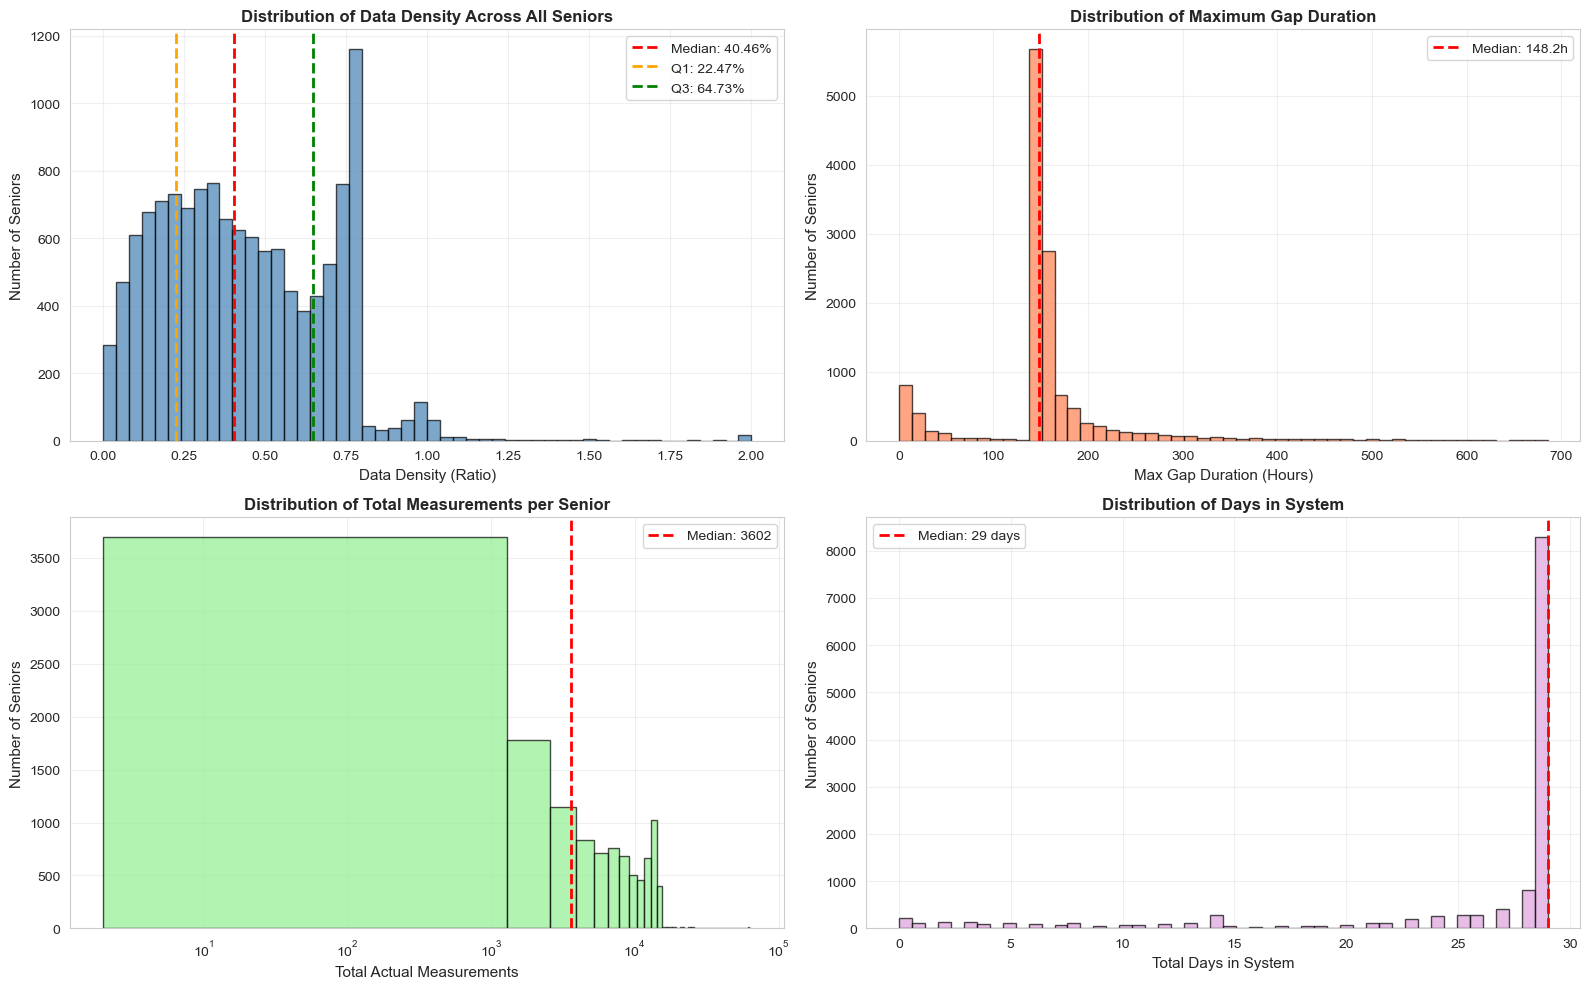

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Data Density Distribution
ax = axes[0, 0]
ax.hist(gap_df['data_density'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(gap_df['data_density'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {gap_df["data_density"].median():.2%}')
ax.axvline(gap_df['data_density'].quantile(0.25), color='orange', linestyle='--', linewidth=2, label=f'Q1: {gap_df["data_density"].quantile(0.25):.2%}')
ax.axvline(gap_df['data_density'].quantile(0.75), color='green', linestyle='--', linewidth=2, label=f'Q3: {gap_df["data_density"].quantile(0.75):.2%}')
ax.set_xlabel('Data Density (Ratio)', fontsize=11)
ax.set_ylabel('Number of Seniors', fontsize=11)
ax.set_title('Distribution of Data Density Across All Seniors', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. Max Gap Duration Distribution
ax = axes[0, 1]
ax.hist(gap_df['max_gap_duration_hours'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(gap_df['max_gap_duration_hours'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {gap_df["max_gap_duration_hours"].median():.1f}h')
ax.set_xlabel('Max Gap Duration (Hours)', fontsize=11)
ax.set_ylabel('Number of Seniors', fontsize=11)
ax.set_title('Distribution of Maximum Gap Duration', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. Total Measurements Distribution
ax = axes[1, 0]
ax.hist(gap_df['total_actual_measurements'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax.axvline(gap_df['total_actual_measurements'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {gap_df["total_actual_measurements"].median():.0f}')
ax.set_xlabel('Total Actual Measurements', fontsize=11)
ax.set_ylabel('Number of Seniors', fontsize=11)
ax.set_title('Distribution of Total Measurements per Senior', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.legend()
ax.grid(alpha=0.3)

# 4. Total Days in System Distribution
ax = axes[1, 1]
ax.hist(gap_df['total_days_in_system'], bins=50, color='plum', edgecolor='black', alpha=0.7)
ax.axvline(gap_df['total_days_in_system'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {gap_df["total_days_in_system"].median():.0f} days')
ax.set_xlabel('Total Days in System', fontsize=11)
ax.set_ylabel('Number of Seniors', fontsize=11)
ax.set_title('Distribution of Days in System', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Quality Cutoff Analysis

Evaluate different data_density thresholds and calculate the impact on seniors and alerts.

In [15]:
alerts_df = pd.read_sql_query(
    "SELECT senior_id, severity FROM alerts WHERE severity = 3",
    conn
)

severity_3_alerts = alerts_df.groupby('senior_id').size().reset_index(name='severity_3_alert_count')

gap_df_merged = gap_df.merge(severity_3_alerts, on='senior_id', how='left')
gap_df_merged['severity_3_alert_count'] = gap_df_merged['severity_3_alert_count'].fillna(0).astype(int)

print(f"Total Severity 3 Alerts: {gap_df_merged['severity_3_alert_count'].sum():,}")
print(f"Seniors with Severity 3 Alerts: {(gap_df_merged['severity_3_alert_count'] > 0).sum():,}")

cutoff_thresholds = [0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
cutoff_analysis = []

print("\n" + "=" * 100)
print("QUALITY CUTOFF ANALYSIS")
print("=" * 100)

for cutoff in cutoff_thresholds:
    high_quality = gap_df_merged[gap_df_merged['data_density'] >= cutoff]
    low_quality = gap_df_merged[gap_df_merged['data_density'] < cutoff]
    
    high_quality_count = len(high_quality)
    low_quality_count = len(low_quality)
    high_quality_alerts = high_quality['severity_3_alert_count'].sum()
    low_quality_alerts = low_quality['severity_3_alert_count'].sum()
    
    cutoff_analysis.append({
        'Cutoff Threshold': f'{cutoff:.0%}',
        'High Quality Seniors': high_quality_count,
        'Low Quality Seniors': low_quality_count,
        'High Quality % of Total': f'{100*high_quality_count/len(gap_df_merged):.1f}%',
        'Severity 3 in High Quality': high_quality_alerts,
        'Severity 3 in Low Quality': low_quality_alerts,
        'Severity 3 Lost': low_quality_alerts,
        'Severity 3 Loss %': f'{100*low_quality_alerts/(high_quality_alerts+low_quality_alerts):.1f}%' if (high_quality_alerts+low_quality_alerts) > 0 else '0%'
    })

cutoff_analysis_df = pd.DataFrame(cutoff_analysis)
print("\n" + cutoff_analysis_df.to_string(index=False))

recommended_cutoff = 0.30
print("\n" + "=" * 100)
print(f"RECOMMENDED QUALITY CUTOFF: {recommended_cutoff:.0%}")
print("=" * 100)
high_quality_30 = gap_df_merged[gap_df_merged['data_density'] >= recommended_cutoff]
low_quality_30 = gap_df_merged[gap_df_merged['data_density'] < recommended_cutoff]

print(f"High Quality Seniors (>= 30% density): {len(high_quality_30):,}")
print(f"Low Quality Seniors (< 30% density): {len(low_quality_30):,}")
print(f"Percentage retained: {100*len(high_quality_30)/len(gap_df_merged):.1f}%")
print(f"Severity 3 Alerts retained: {high_quality_30['severity_3_alert_count'].sum():,}")
print(f"Severity 3 Alerts lost: {low_quality_30['severity_3_alert_count'].sum():,}")
print(f"Percentage of Severity 3 Alerts lost: {100*low_quality_30['severity_3_alert_count'].sum()/(high_quality_30['severity_3_alert_count'].sum()+low_quality_30['severity_3_alert_count'].sum()):.1f}%")

Total Severity 3 Alerts: 61
Seniors with Severity 3 Alerts: 57

QUALITY CUTOFF ANALYSIS

Cutoff Threshold  High Quality Seniors  Low Quality Seniors High Quality % of Total  Severity 3 in High Quality  Severity 3 in Low Quality  Severity 3 Lost Severity 3 Loss %
             25%                  9120                 3687                   71.2%                          49                         12               12             19.7%
             30%                  8267                 4540                   64.6%                          46                         15               15             24.6%
             40%                  6475                 6332                   50.6%                          37                         24               24             39.3%
             50%                  4966                 7841                   38.8%                          28                         33               33             54.1%
             60%                  3673   

## Section 8: Summary Report - High vs Low Quality Seniors

In [16]:
gap_df_merged['quality_tier'] = gap_df_merged['data_density'].apply(
    lambda x: 'High Quality' if x >= 0.50 else 'Low Quality'
)

print("\n" + "=" * 100)
print("COMPREHENSIVE DATA QUALITY SUMMARY REPORT")
print("=" * 100)

summary_stats = []

for quality_tier in ['High Quality', 'Low Quality']:
    subset = gap_df_merged[gap_df_merged['quality_tier'] == quality_tier]
    
    summary_stats.append({
        'Quality Tier': quality_tier,
        'Senior Count': len(subset),
        '% of Total': f'{100*len(subset)/len(gap_df_merged):.1f}%',
        'Avg Data Density': f'{subset["data_density"].mean():.1%}',
        'Median Data Density': f'{subset["data_density"].median():.1%}',
        'Avg Measurements': f'{subset["total_actual_measurements"].mean():.0f}',
        'Avg Days in System': f'{subset["total_days_in_system"].mean():.0f}',
        'Avg Max Gap (hrs)': f'{subset["max_gap_duration_hours"].mean():.1f}',
        'Total Severity 3 Alerts': subset['severity_3_alert_count'].sum(),
        'Avg Alerts per Senior': f'{subset["severity_3_alert_count"].mean():.2f}'
    })

summary_report_df = pd.DataFrame(summary_stats)
print("\n" + summary_report_df.to_string(index=False))


COMPREHENSIVE DATA QUALITY SUMMARY REPORT

Quality Tier  Senior Count % of Total Avg Data Density Median Data Density Avg Measurements Avg Days in System Avg Max Gap (hrs)  Total Severity 3 Alerts Avg Alerts per Senior
High Quality          4966      38.8%            70.3%               71.0%            10329                 25             125.5                       28                  0.01
 Low Quality          7841      61.2%            26.4%               26.4%             2441                 25             170.2                       33                  0.00


## Section 9: Quality Tier Comparison Visualizations

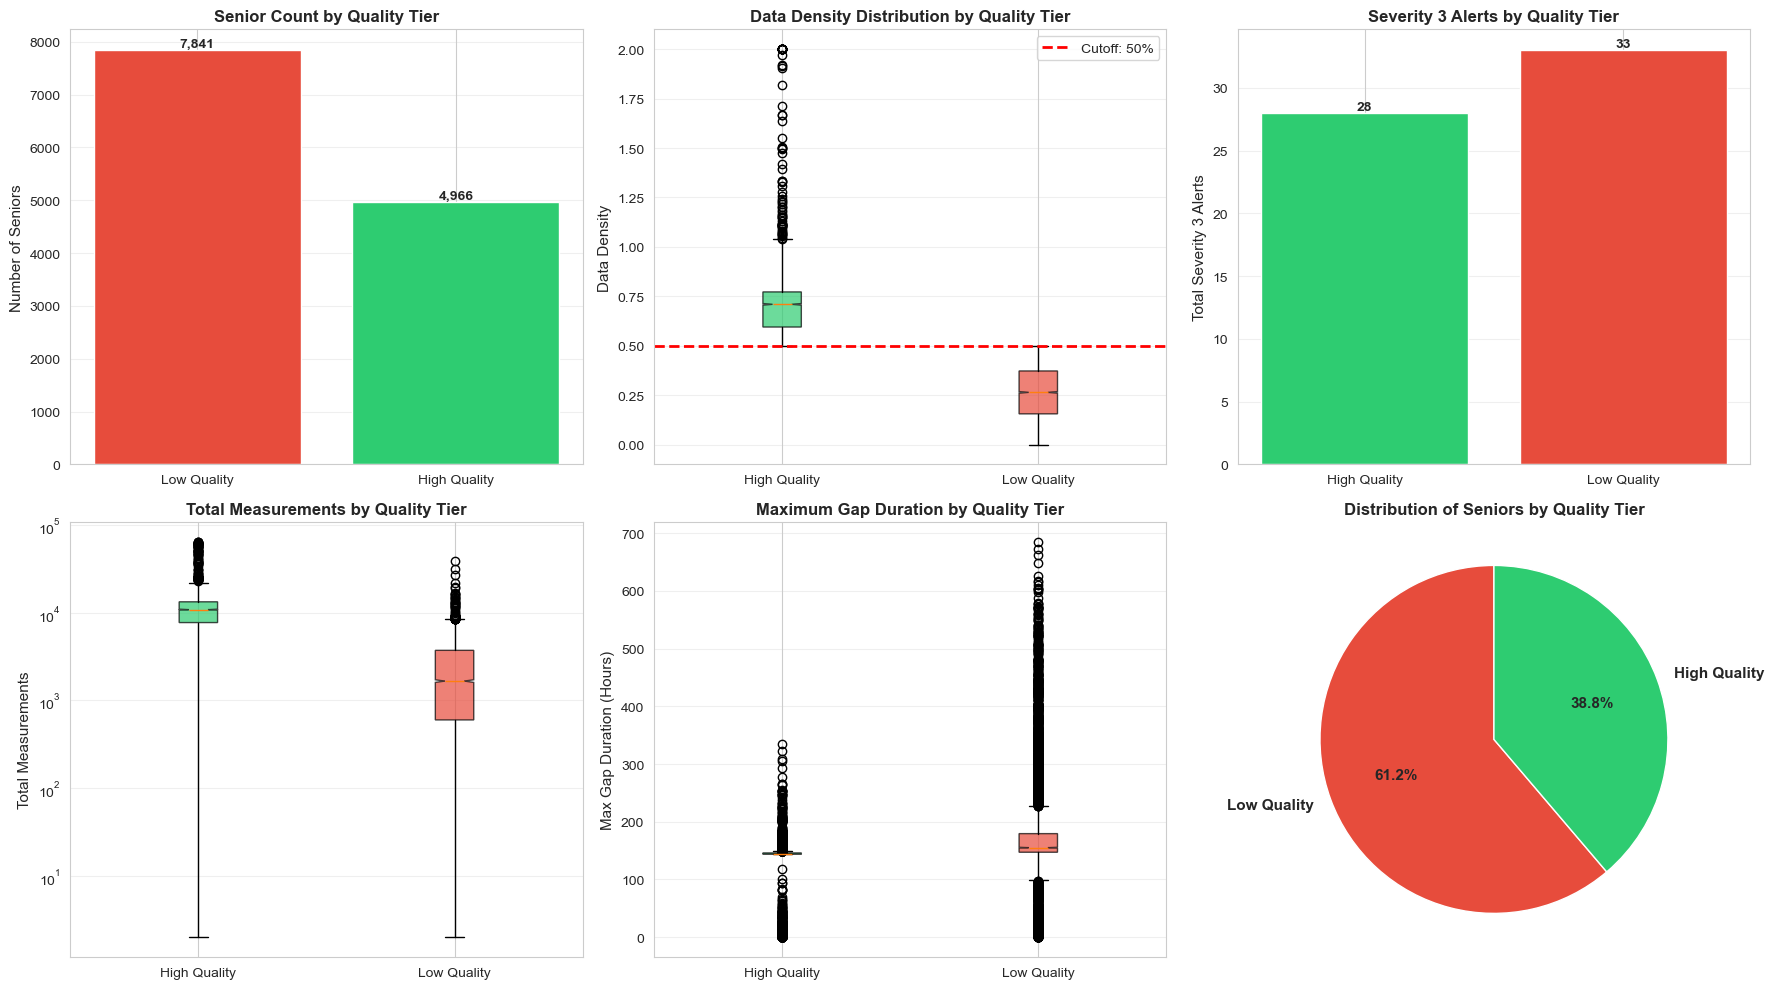

Quality tier comparison plots saved to reports/02_quality_tier_comparison.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = {'High Quality': '#2ecc71', 'Low Quality': '#e74c3c'}

# 1. Senior count by quality tier
ax = axes[0, 0]
quality_counts = gap_df_merged['quality_tier'].value_counts()
bars = ax.bar(quality_counts.index, quality_counts.values, color=[colors[tier] for tier in quality_counts.index])
ax.set_ylabel('Number of Seniors', fontsize=11)
ax.set_title('Senior Count by Quality Tier', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Data density comparison
ax = axes[0, 1]
bp = ax.boxplot([gap_df_merged[gap_df_merged['quality_tier'] == tier]['data_density'].values 
                   for tier in ['High Quality', 'Low Quality']],
                  labels=['High Quality', 'Low Quality'],
                  patch_artist=True,
                  notch=True)
for patch, tier in zip(bp['boxes'], ['High Quality', 'Low Quality']):
    patch.set_facecolor(colors[tier])
    patch.set_alpha(0.7)
ax.axhline(y=0.50, color='red', linestyle='--', linewidth=2, label='Cutoff: 50%')
ax.set_ylabel('Data Density', fontsize=11)
ax.set_title('Data Density Distribution by Quality Tier', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.legend()

# 3. Severity 3 Alerts by quality tier
ax = axes[0, 2]
alert_counts = gap_df_merged.groupby('quality_tier')['severity_3_alert_count'].sum()
bars = ax.bar(alert_counts.index, alert_counts.values, color=[colors[tier] for tier in alert_counts.index])
ax.set_ylabel('Total Severity 3 Alerts', fontsize=11)
ax.set_title('Severity 3 Alerts by Quality Tier', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Total measurements comparison
ax = axes[1, 0]
bp = ax.boxplot([gap_df_merged[gap_df_merged['quality_tier'] == tier]['total_actual_measurements'].values 
                   for tier in ['High Quality', 'Low Quality']],
                  labels=['High Quality', 'Low Quality'],
                  patch_artist=True,
                  notch=True)
for patch, tier in zip(bp['boxes'], ['High Quality', 'Low Quality']):
    patch.set_facecolor(colors[tier])
    patch.set_alpha(0.7)
ax.set_ylabel('Total Measurements', fontsize=11)
ax.set_title('Total Measurements by Quality Tier', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.grid(alpha=0.3, axis='y')

# 5. Max gap duration comparison
ax = axes[1, 1]
bp = ax.boxplot([gap_df_merged[gap_df_merged['quality_tier'] == tier]['max_gap_duration_hours'].values 
                   for tier in ['High Quality', 'Low Quality']],
                  labels=['High Quality', 'Low Quality'],
                  patch_artist=True,
                  notch=True)
for patch, tier in zip(bp['boxes'], ['High Quality', 'Low Quality']):
    patch.set_facecolor(colors[tier])
    patch.set_alpha(0.7)
ax.set_ylabel('Max Gap Duration (Hours)', fontsize=11)
ax.set_title('Maximum Gap Duration by Quality Tier', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# 6. Quality tier pie chart
ax = axes[1, 2]
quality_counts = gap_df_merged['quality_tier'].value_counts()
wedges, texts, autotexts = ax.pie(quality_counts.values, 
                                    labels=quality_counts.index,
                                    colors=[colors[tier] for tier in quality_counts.index],
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Distribution of Seniors by Quality Tier', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/02_quality_tier_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Quality tier comparison plots saved to reports/02_quality_tier_comparison.png")

## Section 10: Alert-Centric Data Quality Audit - Gold Dataset

For every Severity 2 and 3 alert, we'll analyze the 6 hours immediately preceding the alert to calculate **local density** (HR/BP readings in that critical window).

### Gold Dataset Criteria:
1. **Keep all seniors with >30% overall data density**
2. **ADD BACK any senior (regardless of overall density) who has >80% local density in the 6 hours before a Severity 3 alert**

In [18]:
print("Loading Severity 2 and 3 alerts...")
alerts_critical_df = pd.read_sql_query(
    "SELECT event_id, senior_id, alert_date, severity FROM alerts WHERE severity IN (2, 3)",
    conn
)
alerts_critical_df['alert_date'] = pd.to_datetime(alerts_critical_df['alert_date'])

print(f"Total Severity 2 & 3 Alerts: {len(alerts_critical_df):,}")
print(f"  - Severity 2: {(alerts_critical_df['severity'] == 2).sum():,}")
print(f"  - Severity 3: {(alerts_critical_df['severity'] == 3).sum():,}")
print(f"Unique seniors with Severity 2/3 alerts: {alerts_critical_df['senior_id'].nunique():,}")

print("\nLoading HR, BP, and other measurements...")
measurements_hr_bp_df = df[df['type'].isin(['Heartrate', 'BloodPressure', 'Temperature', 'Saturation', 'Steps'])].copy()

print(f"Total measurements: {len(measurements_hr_bp_df):,}")
for mtype in measurements_hr_bp_df['type'].unique():
    count = len(measurements_hr_bp_df[measurements_hr_bp_df['type'] == mtype])
    print(f"  - {mtype}: {count:,}")

Loading Severity 2 and 3 alerts...
Total Severity 2 & 3 Alerts: 317
  - Severity 2: 256
  - Severity 3: 61
Unique seniors with Severity 2/3 alerts: 268

Loading HR, BP, and other measurements...
Total measurements: 70,428,508
  - BloodPressure: 15,934,356
  - Heartrate: 15,934,359
  - Saturation: 12,719,386
  - Steps: 9,973,092
  - Temperature: 15,867,315


In [19]:
print("\nCalculating local density for 6-hour window before each alert...")

local_density_results = []

for idx, alert_row in alerts_critical_df.iterrows():
    if (idx + 1) % 500 == 0:
        print(f"Progress: {idx + 1}/{len(alerts_critical_df)} alerts processed...")
    
    senior_id = alert_row['senior_id']
    alert_date = alert_row['alert_date']
    severity = alert_row['severity']
    
    window_start = alert_date - timedelta(hours=6)
    window_end = alert_date
    
    window_measurements = measurements_hr_bp_df[
        (measurements_hr_bp_df['senior_id'] == senior_id) &
        (measurements_hr_bp_df['date'] >= window_start) &
        (measurements_hr_bp_df['date'] < window_end)
    ]
    
    hr_bp_count = len(window_measurements)
    
    hours_with_data = window_measurements['date'].dt.floor('H').nunique()
    local_density = hours_with_data / 6.0
    
    local_density_results.append({
        'event_id': alert_row['event_id'],
        'senior_id': senior_id,
        'alert_date': alert_date,
        'severity': severity,
        'hr_bp_count_6h_before': hr_bp_count,
        'hours_with_data_6h': hours_with_data,
        'local_density_6h': local_density
    })

local_density_df = pd.DataFrame(local_density_results)

print("\nLocal Density Analysis Complete!")
print(f"Total alerts analyzed: {len(local_density_df):,}")
print("\nLocal Density Summary Statistics:")
print(local_density_df[['hr_bp_count_6h_before', 'hours_with_data_6h', 'local_density_6h']].describe())


Calculating local density for 6-hour window before each alert...

Local Density Analysis Complete!
Total alerts analyzed: 317

Local Density Summary Statistics:
       hr_bp_count_6h_before  hours_with_data_6h  local_density_6h
count             317.000000          317.000000        317.000000
mean               78.533123            3.892744          0.648791
std                83.527432            2.892785          0.482131
min                 0.000000            0.000000          0.000000
25%                 2.000000            1.000000          0.166667
50%                77.000000            5.000000          0.833333
75%               145.000000            7.000000          1.166667
max               692.000000            7.000000          1.166667


In [20]:
print("\n" + "=" * 100)
print("CREATING GOLD DATASET")
print("=" * 100)

# Criterion 1: All seniors with >30% overall data density
gold_seniors_criterion1 = set(gap_df_merged[gap_df_merged['data_density'] > 0.30]['senior_id'].unique())
print(f"\nCriterion 1: Seniors with >30% overall density: {len(gold_seniors_criterion1):,}")

# Criterion 2: Seniors with >80% local density in 6h before Severity 3 alert
severity3_local = local_density_df[local_density_df['severity'] == 3]
high_local_density_severity3 = severity3_local[severity3_local['local_density_6h'] > 0.80]
gold_seniors_criterion2 = set(high_local_density_severity3['senior_id'].unique())
print(f"Criterion 2: Seniors with >80% local density before Severity 3: {len(gold_seniors_criterion2):,}")

gold_seniors = gold_seniors_criterion1.union(gold_seniors_criterion2)
print(f"\nTotal Unique Seniors in Gold Dataset: {len(gold_seniors):,}")

added_by_criterion2 = gold_seniors_criterion2 - gold_seniors_criterion1
print(f"  - From Criterion 1 only: {len(gold_seniors_criterion1):,}")
print(f"  - Added by Criterion 2: {len(added_by_criterion2):,}")
print(f"  - Overlap (in both): {len(gold_seniors_criterion1.intersection(gold_seniors_criterion2)):,}")

severity3_alerts = local_density_df[local_density_df['severity'] == 3]
severity3_alerts_gold = severity3_alerts[severity3_alerts['senior_id'].isin(gold_seniors)]

print(f"\nSeverity 3 Alerts in Gold Dataset: {len(severity3_alerts_gold):,} / {len(severity3_alerts):,} ({100*len(severity3_alerts_gold)/len(severity3_alerts):.1f}%)")

print("\n" + "=" * 100)
print("GOLD DATASET SUMMARY")
print("=" * 100)
print(f"✓ Total Unique Seniors: {len(gold_seniors):,}")
print(f"✓ Total Severity 3 Alerts: {len(severity3_alerts_gold):,}")
print(f"✓ Total Severity 2 & 3 Alerts: {len(local_density_df[local_density_df['senior_id'].isin(gold_seniors)]):,}")

original_seniors = gap_df_merged['senior_id'].nunique()
print(f"\nRetention Rate: {100*len(gold_seniors)/original_seniors:.1f}% of original seniors")

gold_seniors_df = pd.DataFrame({'senior_id': list(gold_seniors)})
gold_seniors_df = gold_seniors_df.merge(gap_df_merged[['senior_id', 'data_density', 'total_actual_measurements']], on='senior_id', how='left')
gold_seniors_df['criterion'] = gold_seniors_df['senior_id'].apply(
    lambda x: 'Both' if x in gold_seniors_criterion1 and x in gold_seniors_criterion2 
    else ('Criterion 2 Only' if x in gold_seniors_criterion2 else 'Criterion 1 Only')
)


CREATING GOLD DATASET

Criterion 1: Seniors with >30% overall density: 8,267
Criterion 2: Seniors with >80% local density before Severity 3: 26

Total Unique Seniors in Gold Dataset: 8,268
  - From Criterion 1 only: 8,267
  - Added by Criterion 2: 1
  - Overlap (in both): 25

Severity 3 Alerts in Gold Dataset: 47 / 61 (77.0%)

GOLD DATASET SUMMARY
✓ Total Unique Seniors: 8,268
✓ Total Severity 3 Alerts: 47
✓ Total Severity 2 & 3 Alerts: 243

Retention Rate: 64.6% of original seniors


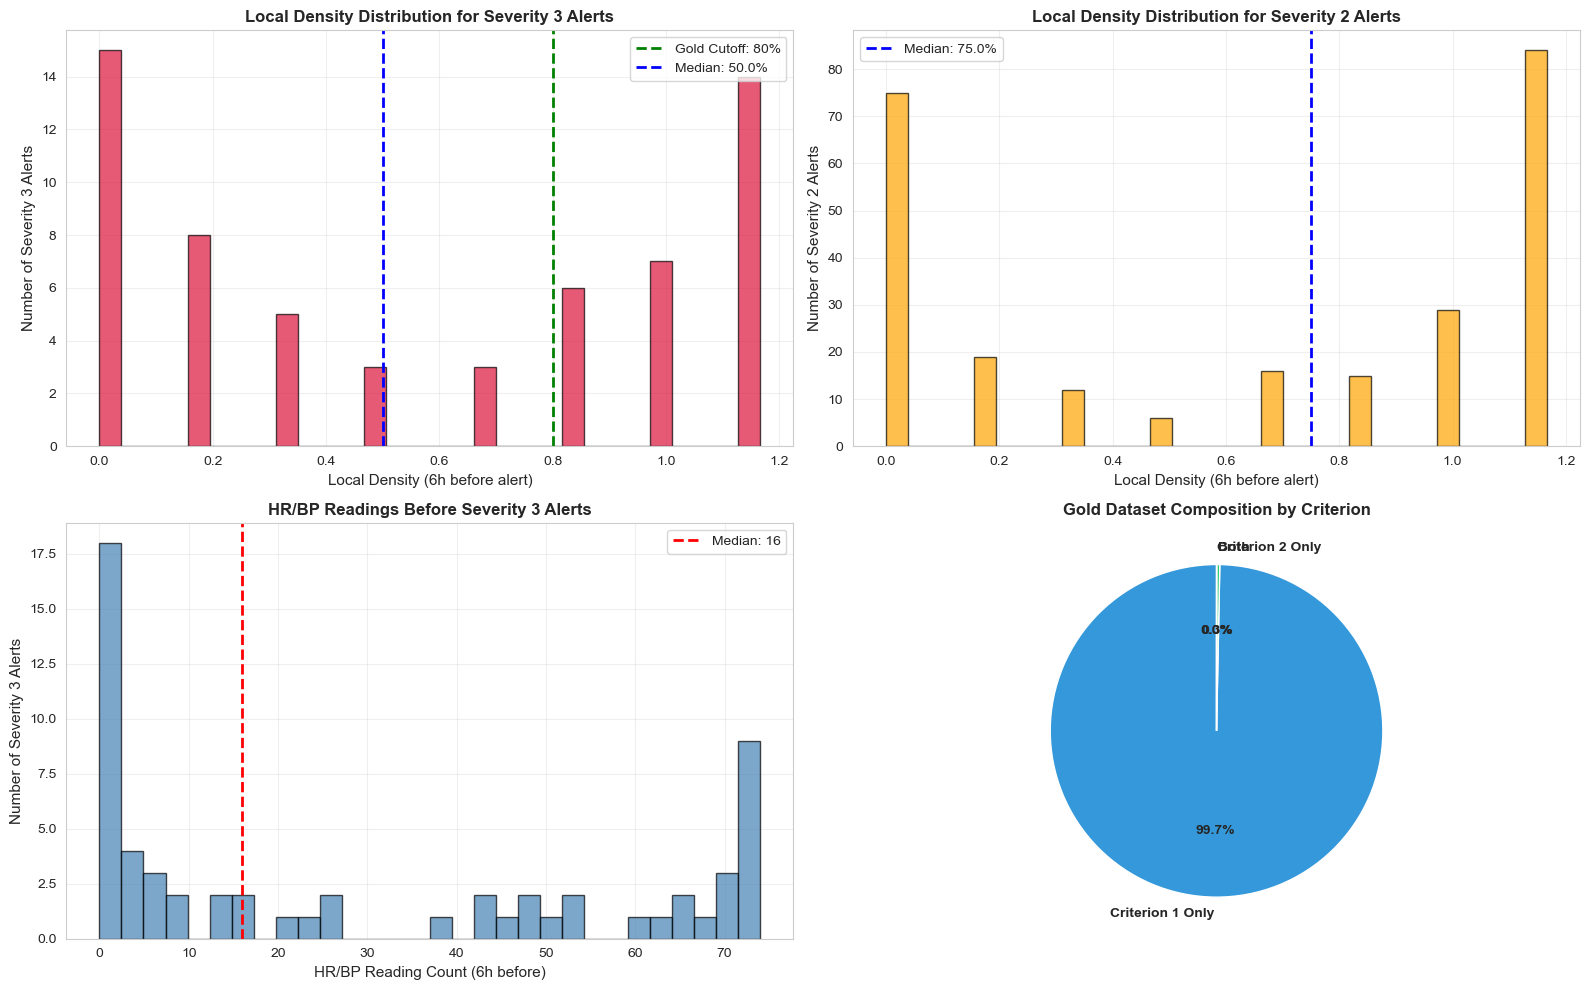

Gold dataset analysis plots saved to reports/04_gold_dataset_analysis.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Local density distribution for Severity 3 alerts
ax = axes[0, 0]
severity3_local = local_density_df[local_density_df['severity'] == 3]
ax.hist(severity3_local['local_density_6h'], bins=30, color='crimson', edgecolor='black', alpha=0.7)
ax.axvline(0.80, color='green', linestyle='--', linewidth=2, label='Gold Cutoff: 80%')
ax.axvline(severity3_local['local_density_6h'].median(), color='blue', linestyle='--', linewidth=2, 
           label=f'Median: {severity3_local["local_density_6h"].median():.1%}')
ax.set_xlabel('Local Density (6h before alert)', fontsize=11)
ax.set_ylabel('Number of Severity 3 Alerts', fontsize=11)
ax.set_title('Local Density Distribution for Severity 3 Alerts', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. Local density distribution for Severity 2 alerts
ax = axes[0, 1]
severity2_local = local_density_df[local_density_df['severity'] == 2]
ax.hist(severity2_local['local_density_6h'], bins=30, color='orange', edgecolor='black', alpha=0.7)
ax.axvline(severity2_local['local_density_6h'].median(), color='blue', linestyle='--', linewidth=2, 
           label=f'Median: {severity2_local["local_density_6h"].median():.1%}')
ax.set_xlabel('Local Density (6h before alert)', fontsize=11)
ax.set_ylabel('Number of Severity 2 Alerts', fontsize=11)
ax.set_title('Local Density Distribution for Severity 2 Alerts', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. HR/BP count distribution before Severity 3 alerts
ax = axes[1, 0]
ax.hist(severity3_local['hr_bp_count_6h_before'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(severity3_local['hr_bp_count_6h_before'].median(), color='red', linestyle='--', linewidth=2, 
           label=f'Median: {severity3_local["hr_bp_count_6h_before"].median():.0f}')
ax.set_xlabel('HR/BP Reading Count (6h before)', fontsize=11)
ax.set_ylabel('Number of Severity 3 Alerts', fontsize=11)
ax.set_title('HR/BP Readings Before Severity 3 Alerts', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 4. Gold Dataset composition pie chart
ax = axes[1, 1]
criterion_counts = gold_seniors_df['criterion'].value_counts()
colors_pie = {'Criterion 1 Only': '#3498db', 'Criterion 2 Only': '#e74c3c', 'Both': '#2ecc71'}
wedges, texts, autotexts = ax.pie(criterion_counts.values, 
                                    labels=criterion_counts.index,
                                    colors=[colors_pie[c] for c in criterion_counts.index],
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 10, 'fontweight': 'bold'})
ax.set_title('Gold Dataset Composition by Criterion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
print("\n" + "=" * 100)
print("GOLD DATASET vs OTHER QUALITY TIERS COMPARISON")
print("=" * 100)

gold_vs_50pct = pd.DataFrame([
    {
        'Quality Tier': 'Gold Dataset (>30% OR >80% local)',
        'Seniors': len(gold_seniors),
        '% of Total': f'{100*len(gold_seniors)/original_seniors:.1f}%',
        'Severity 3 Alerts': len(severity3_alerts_gold),
        '% Severity 3 Retained': f'{100*len(severity3_alerts_gold)/len(severity3_alerts):.1f}%'
    },
    {
        'Quality Tier': 'High Quality (>50% density)',
        'Seniors': len(gap_df_merged[gap_df_merged['data_density'] >= 0.50]),
        '% of Total': f'{100*len(gap_df_merged[gap_df_merged["data_density"] >= 0.50])/original_seniors:.1f}%',
        'Severity 3 Alerts': (gap_df_merged[gap_df_merged['data_density'] >= 0.50]['severity_3_alert_count'].sum()),
        '% Severity 3 Retained': f'{100*(gap_df_merged[gap_df_merged["data_density"] >= 0.50]["severity_3_alert_count"].sum())/gap_df_merged["severity_3_alert_count"].sum():.1f}%'
    },
    {
        'Quality Tier': 'All Seniors',
        'Seniors': original_seniors,
        '% of Total': '100.0%',
        'Severity 3 Alerts': len(severity3_alerts),
        '% Severity 3 Retained': '100.0%'
    }
])

print("\n" + gold_vs_50pct.to_string(index=False))


GOLD DATASET vs OTHER QUALITY TIERS COMPARISON

                     Quality Tier  Seniors % of Total  Severity 3 Alerts % Severity 3 Retained
Gold Dataset (>30% OR >80% local)     8268      64.6%                 47                 77.0%
      High Quality (>50% density)     4966      38.8%                 28                 45.9%
                      All Seniors    12807     100.0%                 61                100.0%


In [22]:
print("=" * 100)
print("FINAL GOLD DATASET SUMMARY")
print("=" * 100)
print(f"Unique Seniors: {len(gold_seniors):,}")
print(f"Severity 3 Alerts: {len(severity3_alerts_gold):,}")
print(f"Retention Rate: {100*len(gold_seniors)/original_seniors:.1f}% of seniors, {100*len(severity3_alerts_gold)/len(severity3_alerts):.1f}% of Severity 3 alerts")

FINAL GOLD DATASET SUMMARY
Unique Seniors: 8,268
Severity 3 Alerts: 47
Retention Rate: 64.6% of seniors, 77.0% of Severity 3 alerts


## Section 11: Save Gold Dataset for Downstream Processing

In [ ]:
print("=" * 100)
print("SAVING GOLD DATASET")
print("=" * 100)

gold_dataset_pickle_path = '../data/processed/gold_seniors.pkl'
with open(gold_dataset_pickle_path, 'wb') as f:
    pickle.dump(gold_seniors, f)

print(f"✓ Gold Dataset (set) saved to: {gold_dataset_pickle_path}")

gold_seniors_csv_path = '../data/processed/gold_seniors.csv'
gold_seniors_df.to_csv(gold_seniors_csv_path, index=False)

print(f"✓ Gold Dataset (detailed) saved to: {gold_seniors_csv_path}")

metadata = {
    'total_seniors': len(gold_seniors),
    'criterion_1_count': len(gold_seniors_criterion1),
    'criterion_2_count': len(gold_seniors_criterion2),
    'overlap_count': len(gold_seniors_criterion1.intersection(gold_seniors_criterion2)),
    'retention_rate_percent': 100 * len(gold_seniors) / original_seniors,
    'severity_3_alerts': len(severity3_alerts_gold),
    'severity_3_retention_percent': 100 * len(severity3_alerts_gold) / len(severity3_alerts),
    'criteria_description': {
        'criterion_1': 'Seniors with >30% overall data density',
        'criterion_2': 'Seniors with >80% local density in 6 hours before Severity 3 alert'
    }
}

metadata_path = '../data/processed/gold_dataset_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Gold Dataset metadata saved to: {metadata_path}")

print("\n" + "=" * 100)
print("GOLD DATASET SAVED SUCCESSFULLY")
print("=" * 100)
print(f"Files created:")
print(f"  1. {gold_dataset_pickle_path} - Binary pickle file with senior IDs (set format)")
print(f"  2. {gold_seniors_csv_path} - CSV file with detailed senior information")
print(f"  3. {metadata_path} - JSON metadata file")
print(f"\nGold Dataset Summary:")
print(f"  - Total Seniors: {len(gold_seniors):,}")
print(f"  - Retention Rate: {100*len(gold_seniors)/original_seniors:.1f}% of original seniors")
print(f"  - Severity 3 Alerts Retained: {len(severity3_alerts_gold):,} ({100*len(severity3_alerts_gold)/len(severity3_alerts):.1f}%)")

conn.close()
print("\n✓ Database connection closed")

SAVING GOLD DATASET
✓ Gold Dataset (set) saved to: ../data/processed/gold_seniors.pkl
✓ Gold Dataset (detailed) saved to: ../data/processed/gold_seniors.csv
✓ Gold Dataset metadata saved to: ../data/processed/gold_dataset_metadata.json

GOLD DATASET SAVED SUCCESSFULLY
Files created:
  1. ../data/processed/gold_seniors.pkl - Binary pickle file with senior IDs (set format)
  2. ../data/processed/gold_seniors.csv - CSV file with detailed senior information
  3. ../data/processed/gold_dataset_metadata.json - JSON metadata file

Gold Dataset Summary:
  - Total Seniors: 8,268
  - Retention Rate: 64.6% of original seniors
  - Severity 3 Alerts Retained: 47 (77.0%)

✓ Database connection closed
